In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from regime_detector import RegimeDetector
from typing import List, Dict
import matplotlib.pyplot as plt


In [2]:
ANN_FACTOR = 252

In [3]:
# ----------------------------
# Load equity curves
# ----------------------------
def load_equity_csv(path: str, name: str, date_col: str = "Date", equity_col: str = "Equity") -> pd.DataFrame:
    """
    CSV columns expected (default): Date, Equity

    Returns Date index with:
      - Equity_<name>
      - Return_<name>  (pct_change of Equity)
    """
    df = pd.read_csv(path, parse_dates=[date_col]).sort_values(date_col)
    df = df[[date_col, equity_col]].rename(columns={date_col: "Date", equity_col: "Equity"})
    df["Equity"] = pd.to_numeric(df["Equity"], errors="coerce")
    df = df.dropna(subset=["Date", "Equity"]).drop_duplicates("Date")
    df = df.set_index("Date").sort_index()
    df["Return"] = df["Equity"].pct_change()
    return df.rename(columns={"Equity": f"Equity_{name}", "Return": f"Return_{name}"})


# ----------------------------
# Metrics (return-based, robust)
# ----------------------------
def compute_perf_metrics_from_returns(ret: pd.Series, ann_factor: int = ANN_FACTOR) -> dict:
    """
    ret: daily returns series (not equity). Index can be irregular; ann_factor still used for scaling.
    """
    ret = pd.Series(ret).dropna()
    n = int(len(ret))
    if n < 30:
        return {"Days": n, "TotalReturn": np.nan, "CAGR": np.nan, "Sharpe": np.nan, "MaxDD": np.nan}

    # Equity curve implied by returns for DD and total return
    eq = (1.0 + ret).cumprod()
    total_return = float(eq.iloc[-1] - 1.0)

    # CAGR from number of periods
    years = n / float(ann_factor)
    cagr = float(eq.iloc[-1] ** (1.0 / years) - 1.0) if years > 0 else np.nan

    r = ret.to_numpy(dtype=float)
    r_std = float(np.std(r, ddof=1))
    sharpe = float((np.mean(r) / r_std) * np.sqrt(ann_factor)) if r_std > 0 else np.nan

    roll_max = eq.cummax()
    max_dd = float((eq / roll_max - 1.0).min())

    return {"Days": n, "TotalReturn": total_return, "CAGR": cagr, "Sharpe": sharpe, "MaxDD": max_dd}



def run_portfolio_regime_test(
    equity_curves: List[dict],
    weights_by_regime: Dict[str, Dict[str, float]],
    detector,  # RegimeDetector (or compatible: has build_regimes and shift_regime_by_one_day attr)
    initial_equity: float = 1_000_000.0,
    normalize_weights: bool = False,
    # Keep these for parity, but the detector owns most regime params
    shift_regime_by_one_day: bool = True,
    missing_data_mode: str = "drop",   # "drop" | "zero_weight"
) -> dict:
    """
    Same as run_portfolio_regime_test, but regimes come from `detector.build_regimes()`.
    Expects detector.build_regimes() returns a DF with index=Date and column "RegimeLabel".
    """

    if missing_data_mode not in ("drop", "zero_weight"):
        raise ValueError("missing_data_mode must be one of: 'drop', 'zero_weight'")

    strategy_names = [c["name"] for c in equity_curves]

    # Validate weights dict includes all strategies for each regime (0.0 allowed)
    missing = []
    for regime, w in weights_by_regime.items():
        for s in strategy_names:
            if s not in w:
                missing.append((regime, s))
    if missing:
        ex = "\n".join([f"  - regime='{r}' missing strategy='{s}'" for r, s in missing[:10]])
        raise ValueError(
            "weights_by_regime is missing some (regime, strategy) entries. Examples:\n"
            f"{ex}\n\nTip: provide every strategy in every regime (set 0.0 to disable)."
        )

    # Load and merge equity curves
    frames = []
    for c in equity_curves:
        frames.append(
            load_equity_csv(
                path=c["csv"],
                name=c["name"],
                date_col=c.get("date_col", "Date"),
                equity_col=c.get("equity_col", "Equity"),
            )
        )
    df = pd.concat(frames, axis=1).sort_index()
    if df.empty:
        raise RuntimeError("No equity curve data loaded.")

    # Build regimes using detector over the same date window
    start_date, end_date = df.index.min(), df.index.max()
    regimes = detector.build_regimes(start_date=start_date, end_date=end_date)

    # Expect detector output column name
    if "RegimeLabel" not in regimes.columns:
        raise RuntimeError("detector.build_regimes() must return a DataFrame containing 'RegimeLabel' column.")

    # Use consistent naming with the old backtest ("Regime")
    regimes = regimes[["RegimeLabel"]].rename(columns={"RegimeLabel": "Regime"}).copy()

    # IMPORTANT: drop warmup/invalid rows (NaN regimes)
    regimes = regimes.dropna(subset=["Regime"])
    if regimes.empty:
        raise RuntimeError("Detector produced no valid regimes (warmup too short? increase history/start date).")

    # Join regimes onto curve dates (inner => only dates where regimes exist)
    out = df.join(regimes, how="inner")
    if out.empty:
        raise RuntimeError("After joining equity curves with regimes, no overlapping dates were found.")

    # Lookahead fix (keep same semantics as before)
    if shift_regime_by_one_day:
        out["Regime"] = out["Regime"].shift(1)
        out = out.dropna(subset=["Regime"])
        if out.empty:
            raise RuntimeError("After shifting Regime by 1 day, no data remains (check overlap / warmup).")

    # Strategy returns
    ret_cols = [f"Return_{s}" for s in strategy_names]

    # Handle missing sleeve returns honestly
    if missing_data_mode == "drop":
        out = out.dropna(subset=ret_cols, how="any")
        if out.empty:
            raise RuntimeError("After dropping missing sleeve returns, no rows remain. Try missing_data_mode='zero_weight'.")
    else:
        # Keep NaNs for now; we will mask weights for missing sleeves per-row
        pass

    # Build weights matrix per day
    W = np.zeros((len(out), len(strategy_names)), dtype=float)
    reg_arr = out["Regime"].astype(str).to_numpy()

    # Precompute base weights per regime (vector per regime)
    base_w = {}
    for regime_name in weights_by_regime:
        base_w[regime_name] = np.array([float(weights_by_regime[regime_name][s]) for s in strategy_names], dtype=float)

    # Strategy return matrix (may contain NaNs if zero_weight mode)
    R = out[ret_cols].to_numpy(dtype=float)

    for i, regime_name in enumerate(reg_arr):
        if regime_name not in base_w:
            raise KeyError(
                f"Regime '{regime_name}' not found in weights_by_regime keys: {list(base_w.keys())}"
            )

        w = base_w[regime_name].copy()

        if missing_data_mode == "zero_weight":
            nan_mask = ~np.isfinite(R[i, :])
            if np.any(nan_mask):
                w[nan_mask] = 0.0

        if normalize_weights:
            denom = float(np.sum(np.abs(w)))
            if denom > 0:
                w = w / denom

        W[i, :] = w

    # Add weight columns
    for j, s in enumerate(strategy_names):
        out[f"W_{s}"] = W[:, j]

    # Portfolio return
    R_safe = np.where(np.isfinite(R), R, 0.0)
    out["PortfolioReturn"] = np.sum(W * R_safe, axis=1)

    # Portfolio equity
    out["PortfolioEquity"] = float(initial_equity) * (1.0 + out["PortfolioReturn"]).cumprod()

    # Metrics overall
    metrics_overall = compute_perf_metrics_from_returns(out["PortfolioReturn"])

    # Metrics by regime
    metrics_by_regime = {}
    for regime_name in ["Stable Risk-On", "Fragile", "Vol Shock", "Crisis"]:
        mask = out["Regime"].astype(str) == regime_name
        if mask.any():
            metrics_by_regime[regime_name] = compute_perf_metrics_from_returns(out.loc[mask, "PortfolioReturn"])
    metrics_by_regime_df = pd.DataFrame(metrics_by_regime).T if metrics_by_regime else pd.DataFrame()

    weights_table = pd.DataFrame(weights_by_regime).T[strategy_names]

    return {
        "portfolio_df": out.reset_index().rename(columns={"index": "Date"}),
        "metrics_overall": metrics_overall,
        "metrics_by_regime": metrics_by_regime_df,
        "weights_table": weights_table,
        "regimes_params": {
            "detector_class": detector.__class__.__name__,
            # Best-effort: capture common detector attrs if present
            "vix_high_pct": getattr(detector, "vix_high_pct", None),
            "spread_wide_pct": getattr(detector, "spread_wide_pct", None),
            "lookback": getattr(detector, "lookback", None),
            "credit_mode": getattr(detector, "credit_mode", None),
            "ema_span": getattr(detector, "ema_span", None),
            "shift_regime_by_one_day": shift_regime_by_one_day,
            "missing_data_mode": missing_data_mode,
        },
    }

In [4]:

# ----------------------------
# Example usage in a notebook
# ----------------------------


# 1) Provide your equity curves (CSV paths)
equity_curves = [
    {"name":"trend", "csv":"data/trend-equity-vt.csv"},
    {"name":"triple_coint", "csv":"data/pairs_portfolio_equity_curve.csv"},
    {"name":"futures_trend", "csv":"data/trend-long-short-futures-oil.csv"},
    {"name":"triple_vol", "csv":"data/volatility-triple-harvester.csv"},
    # {
    #     "name": "collar_overlay", "csv": "data/collar_overlay.csv",
    # },
]

# 3) Provide weights per regime
# weights_by_regime = {
#     "Stable Risk-On": {
#         "trend":1.0, 
#         "triple_coint":0.0, 
#         "futures_trend":0.0, 
#         "triple_vol":0.0
#     },
#     "Fragile":        {
#         "trend":0.00, 
#         "triple_coint":0.60, 
#         "triple_vol":0.40,
#         "futures_trend":0.0, 
#     },
#     "Vol Shock":      {
#         "trend":0.0, 
#         "triple_coint":0.5, 
#         "futures_trend":0.5, 
#         "triple_vol":0.0
#     },
#     "Crisis":         {
#         "trend":0.0, 
#         "futures_trend":0.50, 
#         "triple_coint":0.50, 
#         "triple_vol":0.0
#     },
# }

# weights_by_regime = {
#     "Stable Risk-On": {
#         "trend":1.0, 
#         "triple_coint":0.0, 
#         "futures_trend":0.0, 
#         "triple_vol":0.0,
#         "collar_overlay": 0.0
#     },
#     "Fragile":        {
#         "trend":0.30, 
#         "triple_coint":0.50, 
#         "triple_vol":0.20,
#         "futures_trend":0.0,
#         "collar_overlay": 0.0
#     },
#     "Vol Shock":      {
#         "trend":0.0, 
#         "triple_coint":0.0, 
#         "futures_trend":1.0, 
#         "triple_vol":0.0,
#         "collar_overlay": 0.0
#     },
#     "Crisis":         {
#         "trend":0.0, 
#         "futures_trend":0.00, 
#         "triple_coint":1.00, 
#         "triple_vol":0.0,
#         "collar_overlay": 0.0
#     },
# }


weights_by_regime = {
    "Stable Risk-On": {
        "trend":1.0, 
        "triple_coint":0.0, 
        "futures_trend":0.0, 
        "triple_vol":0.0,
        "collar_overlay": 0.0
    },
    "Fragile":        {
        "trend":0.20, 
        "triple_coint":0.50, 
        "triple_vol":0.03,
        "futures_trend":0.0,
        "collar_overlay": 0.0
    },
    "Vol Shock":      {
        "trend":0.0, 
        "triple_coint":1.0, 
        "futures_trend":0.0, 
        "triple_vol":0.0,
        "collar_overlay": 0.0
    },
    "Crisis":         {
        "trend":0.0, 
        "futures_trend":0.00, 
        "triple_coint":0.40, 
        "triple_vol":0.0,
        "collar_overlay": 0.6
    },
}


detector = RegimeDetector(
    ema_span=60,
    lookback=252,
    vix_high_pct=0.70,
    spread_wide_pct=0.70,
    credit_mode="ratio",
    shift_regime_by_one_day=True,
)

res = run_portfolio_regime_test(
    equity_curves=equity_curves,
    weights_by_regime=weights_by_regime,
    detector=detector,
    initial_equity=10_000.0,
    normalize_weights=False,
    shift_regime_by_one_day=True,
    missing_data_mode="drop",
)

res["metrics_overall"]
res["metrics_by_regime"]
res["weights_table"]
res["portfolio_df"].head()


,Date,Equity_trend,Return_trend,Equity_triple_coint,Return_triple_coint,Equity_futures_trend,Return_futures_trend,Equity_triple_vol,Return_triple_vol,Regime,W_trend,W_triple_coint,W_futures_trend,W_triple_vol,PortfolioReturn,PortfolioEquity
0,2022-05-06,1.791515,0.000049,1.600954,0.004046,58.18257,0.0,1.0,0.0,Vol Shock,0.0,1.0,0.0,0.0,0.004046,10040.456423
1,2022-05-09,1.760885,-0.017098,1.612151,0.006994,58.18257,0.0,1.0,0.0,Vol Shock,0.0,1.0,0.0,0.0,0.006994,10110.678421
2,2022-05-10,1.754809,-0.003450,1.606564,-0.003466,58.18257,0.0,1.0,0.0,Vol Shock,0.0,1.0,0.0,0.0,-0.003466,10075.639280
3,2022-05-11,1.759714,0.002795,1.601178,-0.003352,58.18257,0.0,1.0,0.0,Vol Shock,0.0,1.0,0.0,0.0,-0.003352,10041.861954
4,2022-05-12,1.739720,-0.011362,1.597771,-0.002128,58.18257,0.0,1.0,0.0,Vol Shock,0.0,1.0,0.0,0.0,-0.002128,10020.493675


In [5]:


def compute_perf_metrics_from_equity(equity: pd.Series) -> dict:
    equity = equity.dropna()
    if len(equity) < 30:
        return {"Days": int(len(equity)), "TotalReturn": np.nan, "CAGR": np.nan, "Sharpe": np.nan, "MaxDD": np.nan}

    ret = equity.pct_change().dropna()
    r = ret.to_numpy()
    r_std = float(np.std(r, ddof=1))
    sharpe = float((np.mean(r) / r_std) * np.sqrt(ANN_FACTOR)) if r_std > 0 else np.nan

    total_return = float(equity.iloc[-1] / equity.iloc[0] - 1)
    cagr = float((equity.iloc[-1] / equity.iloc[0]) ** (ANN_FACTOR / len(equity)) - 1)

    roll_max = equity.cummax()
    max_dd = float((equity / roll_max - 1).min())

    return {"Days": int(len(equity)), "TotalReturn": total_return, "CAGR": cagr, "Sharpe": sharpe, "MaxDD": max_dd}


def build_benchmark_equity_from_yfinance(
    ticker: str,
    start_date,
    end_date,
    initial_equity: float,
) -> pd.Series:
    px = yf.download(
        [ticker],
        start=pd.to_datetime(start_date).date(),
        end=pd.to_datetime(end_date).date(),
        auto_adjust=False, progress=False
    )["Adj Close"]

    if isinstance(px, pd.DataFrame):
        px = px[ticker]

    px = px.dropna()
    if px.empty:
        raise RuntimeError(f"yfinance returned no prices for benchmark ticker='{ticker}'")

    # Normalize to initial_equity
    bench_equity = initial_equity * (px / px.iloc[0])
    bench_equity.name = f"{ticker}_Equity"
    return bench_equity


def plot_portfolio_vs_benchmark(
    res: dict,
    benchmark_ticker: str = "SPY",
    initial_equity: float | None = None,
    title: str | None = None,
):
    """
    res: output of run_portfolio_regime_test(...), must contain res["portfolio_df"]
         with columns: Date, PortfolioEquity
    benchmark_ticker: e.g. "SPY"
    initial_equity: if None, inferred from portfolio curve's first value
    """
    port = res["portfolio_df"].copy()
    if "Date" not in port.columns or "PortfolioEquity" not in port.columns:
        raise ValueError("res['portfolio_df'] must include columns: Date, PortfolioEquity")

    port["Date"] = pd.to_datetime(port["Date"])
    port = port.sort_values("Date").set_index("Date")
    port_eq = port["PortfolioEquity"].dropna()

    if port_eq.empty:
        raise RuntimeError("Portfolio equity curve is empty after dropping NaNs.")

    if initial_equity is None:
        initial_equity = float(port_eq.iloc[0])

    start_date = port_eq.index.min()
    end_date = port_eq.index.max()

    bench_eq = build_benchmark_equity_from_yfinance(
        ticker=benchmark_ticker,
        start_date=start_date,
        end_date=end_date,
        initial_equity=initial_equity,
    )

    # Align (inner join on common dates)
    aligned = pd.concat([port_eq.rename("Portfolio"), bench_eq.rename(benchmark_ticker)], axis=1).dropna()

    # Metrics
    port_m = compute_perf_metrics_from_equity(aligned["Portfolio"])
    bench_m = compute_perf_metrics_from_equity(aligned[benchmark_ticker])

    metrics_df = pd.DataFrame([port_m, bench_m], index=["Portfolio", benchmark_ticker])

    # Plot (single chart, no manual colors)
    plt.figure(figsize=(11, 5))
    plt.plot(aligned.index, aligned["Portfolio"], label="Portfolio")
    plt.plot(aligned.index, aligned[benchmark_ticker], label=benchmark_ticker)
    plt.title(title or f"Portfolio vs {benchmark_ticker}")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "aligned_equity": aligned,
        "metrics": metrics_df,
    }




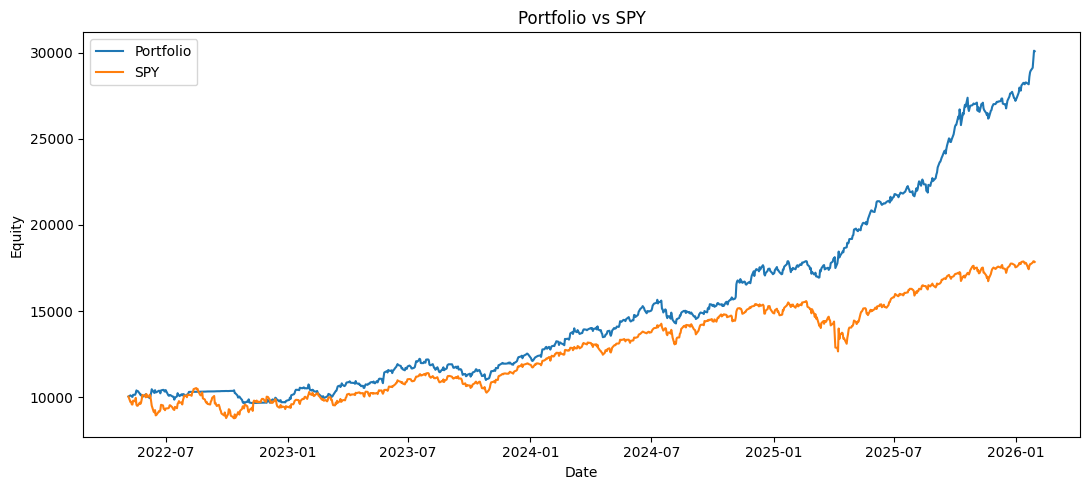

,Portfolio,SPY
Date,,
2022-05-06,10040.456423,10040.456423
2022-05-09,10110.678421,9718.988633
2022-05-10,10075.639280,9741.443548
2022-05-11,10041.861954,9586.688446
2022-05-12,10020.493675,9576.681544


In [6]:

out = plot_portfolio_vs_benchmark(res, benchmark_ticker="SPY")
out["metrics"]
out["aligned_equity"].head()


In [7]:

def add_strategy_and_portfolio_metrics(result: dict, strategy_names: list[str]) -> dict:
    """
    Drop-in helper.

    Inputs
    ------
    result:
      Output dict from run_portfolio_regime_test() (the drop-in version I gave you),
      containing:
        - result["portfolio_df"] with columns:
            Date, PortfolioEquity, Equity_<strategy> (optional), etc.
        - result["metrics_overall"] (portfolio metrics already computed)

    strategy_names:
      List like ["trend", "pairs", "triple_coint", ...]

    Output
    ------
    Adds:
      - result["metrics_by_strategy"]: DataFrame (rows=strategies + "PORTFOLIO")
        cols: Days, TotalReturn, CAGR, Sharpe, MaxDD
    """
    df = result["portfolio_df"].copy()

    # Ensure Date index
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date").set_index("Date")

    metrics = {}

    # --- portfolio aggregate ---
    if "PortfolioEquity" not in df.columns:
        raise RuntimeError("portfolio_df is missing 'PortfolioEquity'.")
    metrics["PORTFOLIO"] = compute_perf_metrics_from_equity(df["PortfolioEquity"])

    # --- each sleeve / strategy ---
    missing_equity_cols = [s for s in strategy_names if f"Equity_{s}" not in df.columns]
    if missing_equity_cols:
        raise RuntimeError(
            "portfolio_df is missing Equity_<strategy> columns for: "
            f"{missing_equity_cols}. Make sure your CSVs were loaded with load_equity_csv()."
        )

    for s in strategy_names:
        metrics[s] = compute_perf_metrics_from_equity(df[f"Equity_{s}"])

    metrics_df = pd.DataFrame(metrics).T
    # Nice ordering
    metrics_df = metrics_df.loc[["PORTFOLIO"] + strategy_names]

    result["metrics_by_strategy"] = metrics_df
    return result


strategy_names = [c["name"] for c in equity_curves]
result = add_strategy_and_portfolio_metrics(res, strategy_names)
display(res["metrics_by_strategy"])

,Days,TotalReturn,CAGR,Sharpe,MaxDD
PORTFOLIO,937.0,1.873894,0.328320,2.172747,-0.100614
trend,937.0,1.162960,0.230578,1.751665,-0.106140
triple_coint,937.0,1.769111,0.315117,2.366023,-0.094254
futures_trend,937.0,0.559824,0.127006,1.331344,-0.048980
triple_vol,937.0,0.160558,0.040859,8.137177,-0.002987
